In [1]:
import os
import random
import pandas as pd
import json
from tqdm import tqdm
import ast
# Mount to google drive
# from google.colab import drive
# drive.mount('/content/drive')

# Change it to your google drive path where this notebook located.
drive_path = '/Users/samyiin/Projects/ZipfLawAnalysis'
os.chdir(drive_path)

# Gather all data


In [2]:
import os

def count_files(base_directory, file_name):
    count = 0
    # List all subdirectories in the base directory
    for user_dir in os.listdir(base_directory):
        user_path = os.path.join(base_directory, user_dir)
        if os.path.isdir(user_path):
            # file_path = os.path.join(user_path, "python_repo_details.csv")
            # file_path = os.path.join(user_path, "repos.csv")
            # file_path = os.path.join(user_path, "user_info.json")
            file_path = os.path.join(user_path, file_name)
            if os.path.isfile(file_path):
                count += 1
    return count
    
completed = count_files("Database/UserData", "python_repo_details.csv")
completed

49677

In [3]:
completed = count_files("Database/UserData", "repos.csv")
completed

49735

In [4]:
completed = count_files("Database/UserData", "user_info.json")
completed

49757

In [6]:
def join_csv(base_directory, file_name):
    list_df = []
    # List all subdirectories in the base directory
    for user_dir in os.listdir(base_directory):
        user_path = os.path.join(base_directory, user_dir)
        if os.path.isdir(user_path):
            file_path = os.path.join(user_path, file_name)
            if os.path.isfile(file_path):
                df = pd.read_csv(file_path)
                list_df.append(df)
    combined_df = pd.concat(list_df, ignore_index=True)
    return combined_df

def load_python_repos(python_repo_csv_path):
    if not os.path.exists(python_repo_csv_path):
        df_python_repos = join_csv("Database/UserData", "python_repo_details.csv")
        df_python_repos.to_csv(python_repo_csv_path, index=False)
    else:
        df_python_repos = pd.read_csv(python_repo_csv_path)
    return df_python_repos
python_repo_csv_path = 'Database/TempData/GatherData/Filter_3_UserRepositories/TempResults/python_repos.csv'
df_python_repos = load_python_repos(python_repo_csv_path)
df_python_repos['contributors'] = df_python_repos['contributors'].apply(lambda x: ast.literal_eval(x))
df_python_repos['language_details'] = df_python_repos['language_details'].apply(lambda x: ast.literal_eval(x))

# Statistics

In [7]:
import ast  
df_statistics = pd.DataFrame()
df_statistics['python_size_byte'] = df_python_repos['language_details'].apply(lambda x: x.get('Python', 0))
df_statistics['project_size_byte'] = df_python_repos['size']*1024

def calculate_python_size_percentage(row):
    if row['project_size_byte'] == 0:
        return -1
    else:
        return row['python_size_byte']/row['project_size_byte']
    
df_statistics['python_percentage'] = df_statistics[['python_size_byte','project_size_byte']].apply(calculate_python_size_percentage, axis=1)

df_statistics['number_contributors'] = df_python_repos['contributors'].apply(len)

def get_total_contributions(contributors):
    total_contributions = 0
    for contributor_dic in contributors:
        total_contributions += contributor_dic['contributions']
    return total_contributions

df_statistics['total_contributions'] = df_python_repos['contributors'].apply(get_total_contributions)

def get_owner_contributions(row):
    owner_contributions = 0
    for contributor_dic in row['contributors']:
        if contributor_dic['login'] == row['user_login']:
            owner_contributions += contributor_dic['contributions']
    return owner_contributions
df_statistics['owner_contributions'] = df_python_repos[['user_login', 'contributors']].apply(get_owner_contributions, axis=1)

def get_owner_contribution_percentage(row):
    if row['total_contributions'] == 0:
        return -1
    else:
        return row['owner_contributions']/row['total_contributions']

df_statistics['owner_contribution_percentage'] = df_statistics[['owner_contributions', 'total_contributions']].apply(get_owner_contribution_percentage, axis=1)

df_statistics['num_branches'] = df_python_repos['num_branches']

In [8]:
df_statistics

,python_size_byte,project_size_byte,python_percentage,number_contributors,total_contributions,owner_contributions,owner_contribution_percentage,num_branches
0,10264,9216,1.113715,0,0,0,-1.0,1
1,17830101,37249024,0.478673,1,2,2,1.0,1
2,1857,110592,0.016791,1,3,3,1.0,1
3,4355954,6778880,0.642577,1,6,6,1.0,1
4,23925,72704,0.329074,1,9,9,1.0,1
...,...,...,...,...,...,...,...,...
232304,554,36864,0.015028,1,3,3,1.0,1
232305,2455,7168,0.342494,1,8,8,1.0,1
232306,3898,2048,1.903320,1,3,3,1.0,1
232307,5223,245760,0.021252,1,5,5,1.0,1


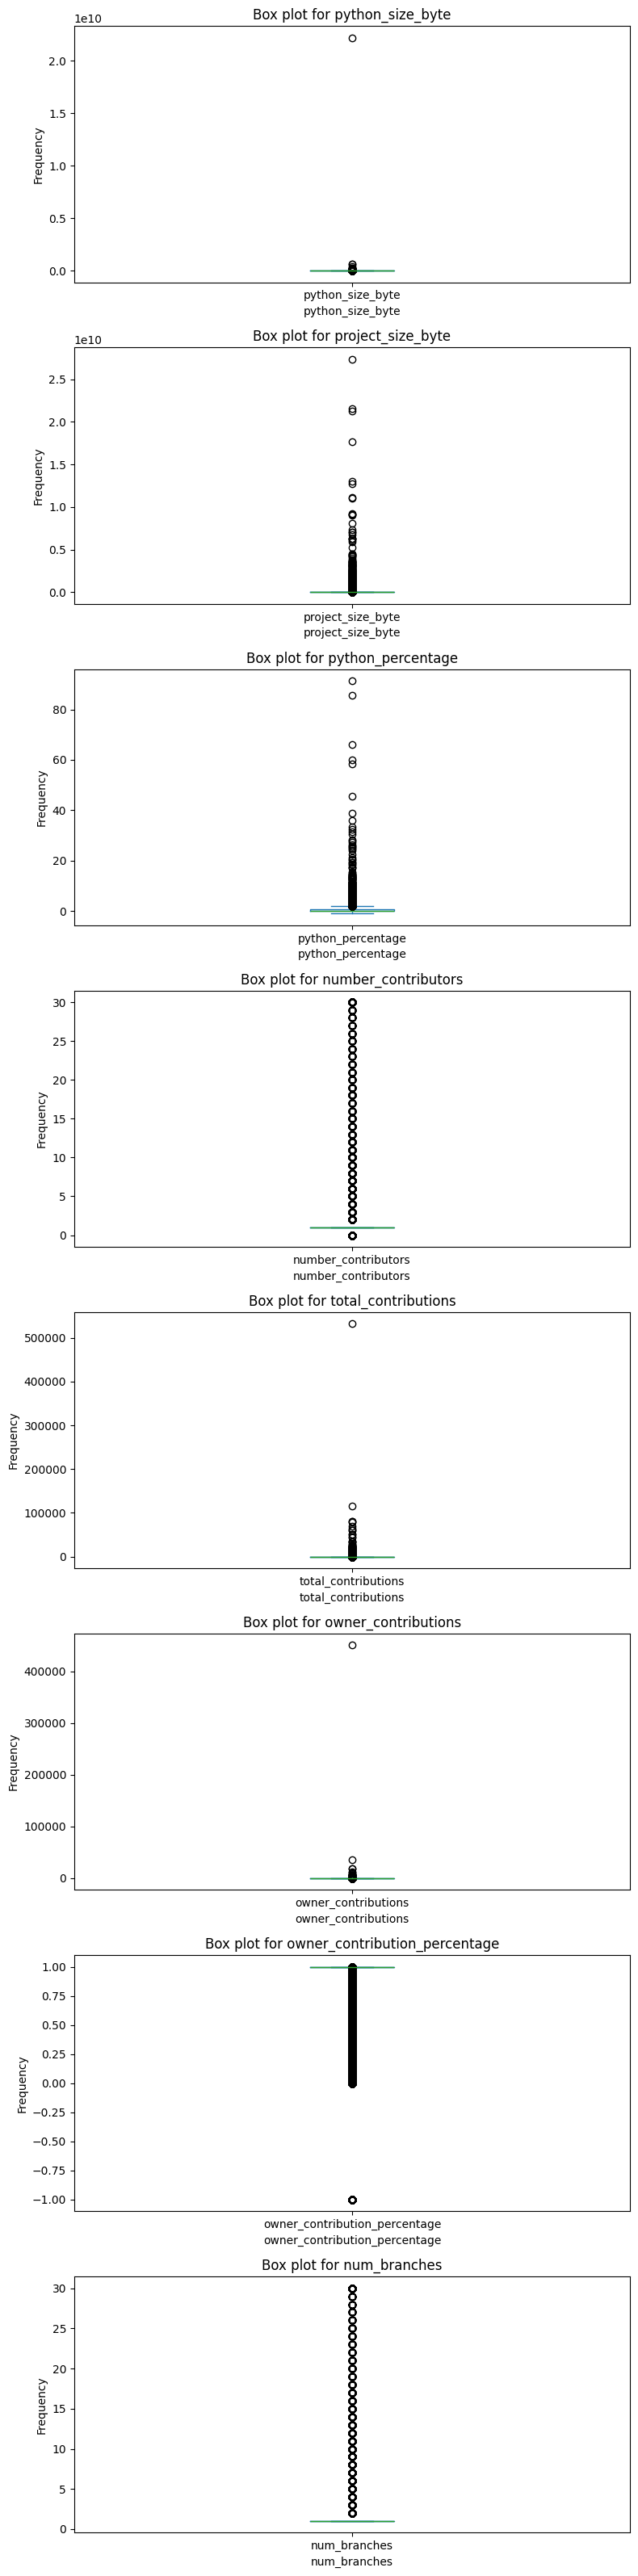

In [9]:
import matplotlib.pyplot as plt

# Subplots
def plot_hist_subplot(df, column_name, ax):
    df[column_name].plot(kind='hist', bins=500, alpha=0.7, ax=ax)
    ax.set_title(f'Histogram for {column}')
    ax.set_xlabel(column_name)
    ax.set_ylabel('Frequency')
    
def plot_box_subplot(df, column_name, ax):
    df[column_name].plot(kind='box', ax=ax)
    ax.set_title(f'Box plot for {column}')
    ax.set_xlabel(column_name)
    ax.set_ylabel('Frequency')
    
num_columns = len(df_statistics.columns)
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(8, 4 * num_columns))
for i, column in enumerate(df_statistics.columns):
    ax = axes[i] if num_columns > 1 else axes
    # plot_hist_subplot(df_statistics, column, ax)
    plot_box_subplot(df_statistics, column,ax)
# Adjust layout
plt.tight_layout()
plt.show()



# df_historgram(df_statistics, 'python_size_byte')

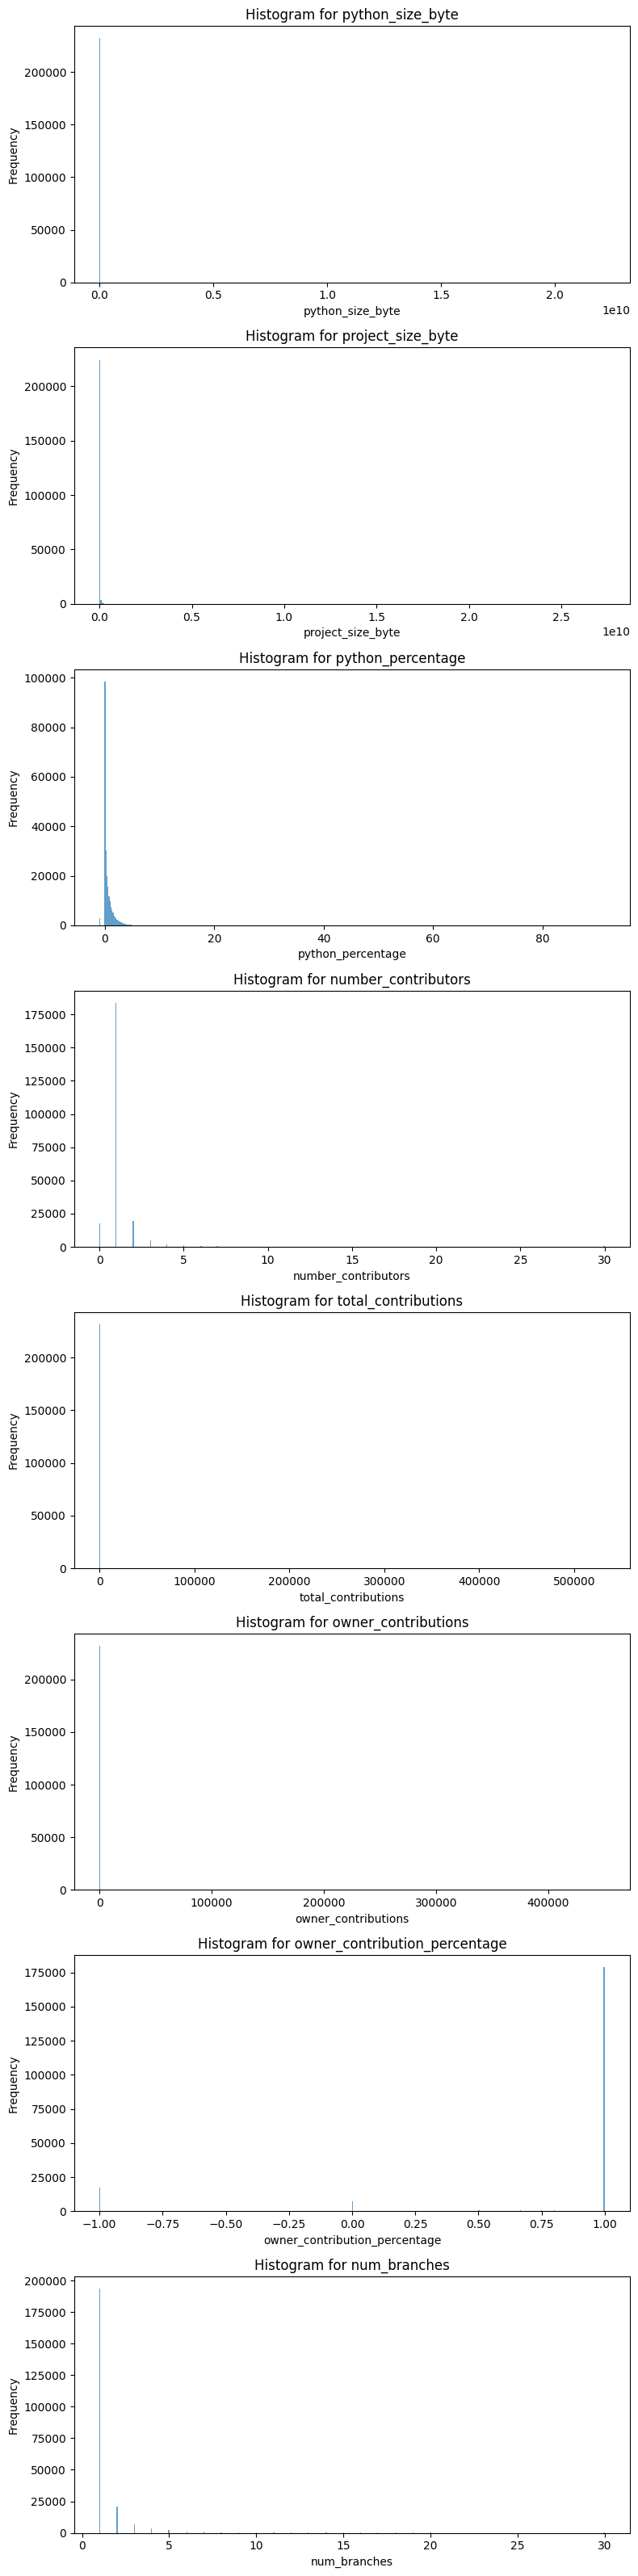

In [10]:
num_columns = len(df_statistics.columns)
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(8, 4 * num_columns))
for i, column in enumerate(df_statistics.columns):
    ax = axes[i] if num_columns > 1 else axes
    plot_hist_subplot(df_statistics, column, ax)
    # plot_box_subplot(df_statistics, column,ax)
# Adjust layout
plt.tight_layout()
plt.show()

# Outliers
We can see that there are clearly some outliers. So we will define outliers using the interquartile range (IQR). There are other ways to handle outliers, like z-value, cluster algo etc. Some are not relavent because we are not normal distribution, some are too fancy, we can come back to this later. 

python_size_byte: Lower Threshold: -47852.5
python_size_byte: Upper Threshold: 91263.5


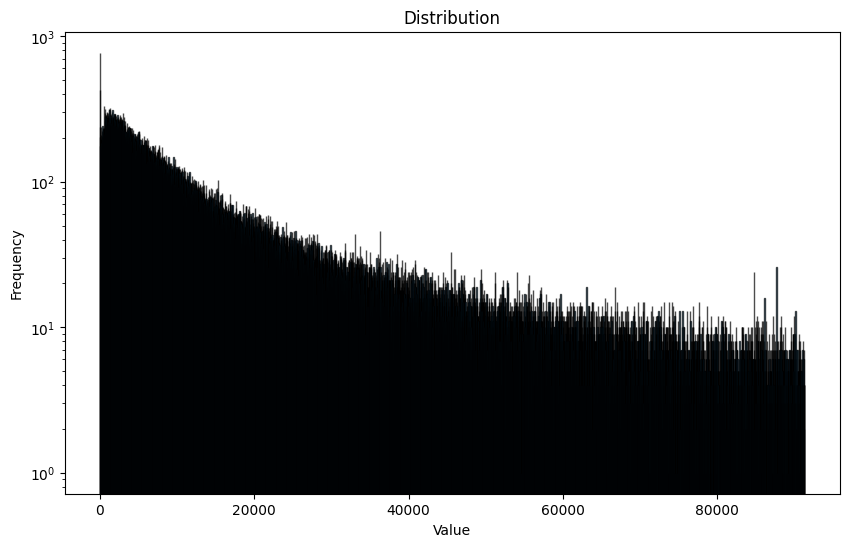

In [11]:
# Not used
def df_historgram(df, column_name):
    plt.figure(figsize=(10, 6))
    plt.hist(df[column_name], bins=5000, alpha=0.7, edgecolor='black',log=True)
    plt.title("Distribution")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

def get_outliers_IQR(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate thresholds
    lower_threshold = Q1 - 1.5 * IQR
    upper_threshold = Q3 + 1.5 * IQR

    print(f"{column_name}: Lower Threshold: {lower_threshold}")
    print(f"{column_name}: Upper Threshold: {upper_threshold}")
    
    return lower_threshold, upper_threshold

def remove_outliers(df, column_name, lower_threshold, upper_threshold):
    df_filtered = df[(df[column_name] >= lower_threshold) & (df[column_name] <= upper_threshold)]
    return df_filtered


column_name = 'python_size_byte'
thresholds = get_outliers_IQR(df_statistics, column_name)
df_filtered = remove_outliers(df_statistics, column_name, *thresholds)
df_historgram(df_filtered, column_name)

python_size_byte: Lower Threshold: -47852.5
python_size_byte: Upper Threshold: 91263.5
project_size_byte: Lower Threshold: -1325568.0
project_size_byte: Upper Threshold: 2242048.0
python_percentage: Lower Threshold: -1.0959050242851907
python_percentage: Upper Threshold: 1.8794180145711143
number_contributors: Lower Threshold: 1.0
number_contributors: Upper Threshold: 1.0
total_contributions: Lower Threshold: -22.0
total_contributions: Upper Threshold: 42.0
owner_contributions: Lower Threshold: -19.0
owner_contributions: Upper Threshold: 37.0
owner_contribution_percentage: Lower Threshold: 1.0
owner_contribution_percentage: Upper Threshold: 1.0
num_branches: Lower Threshold: 1.0
num_branches: Upper Threshold: 1.0


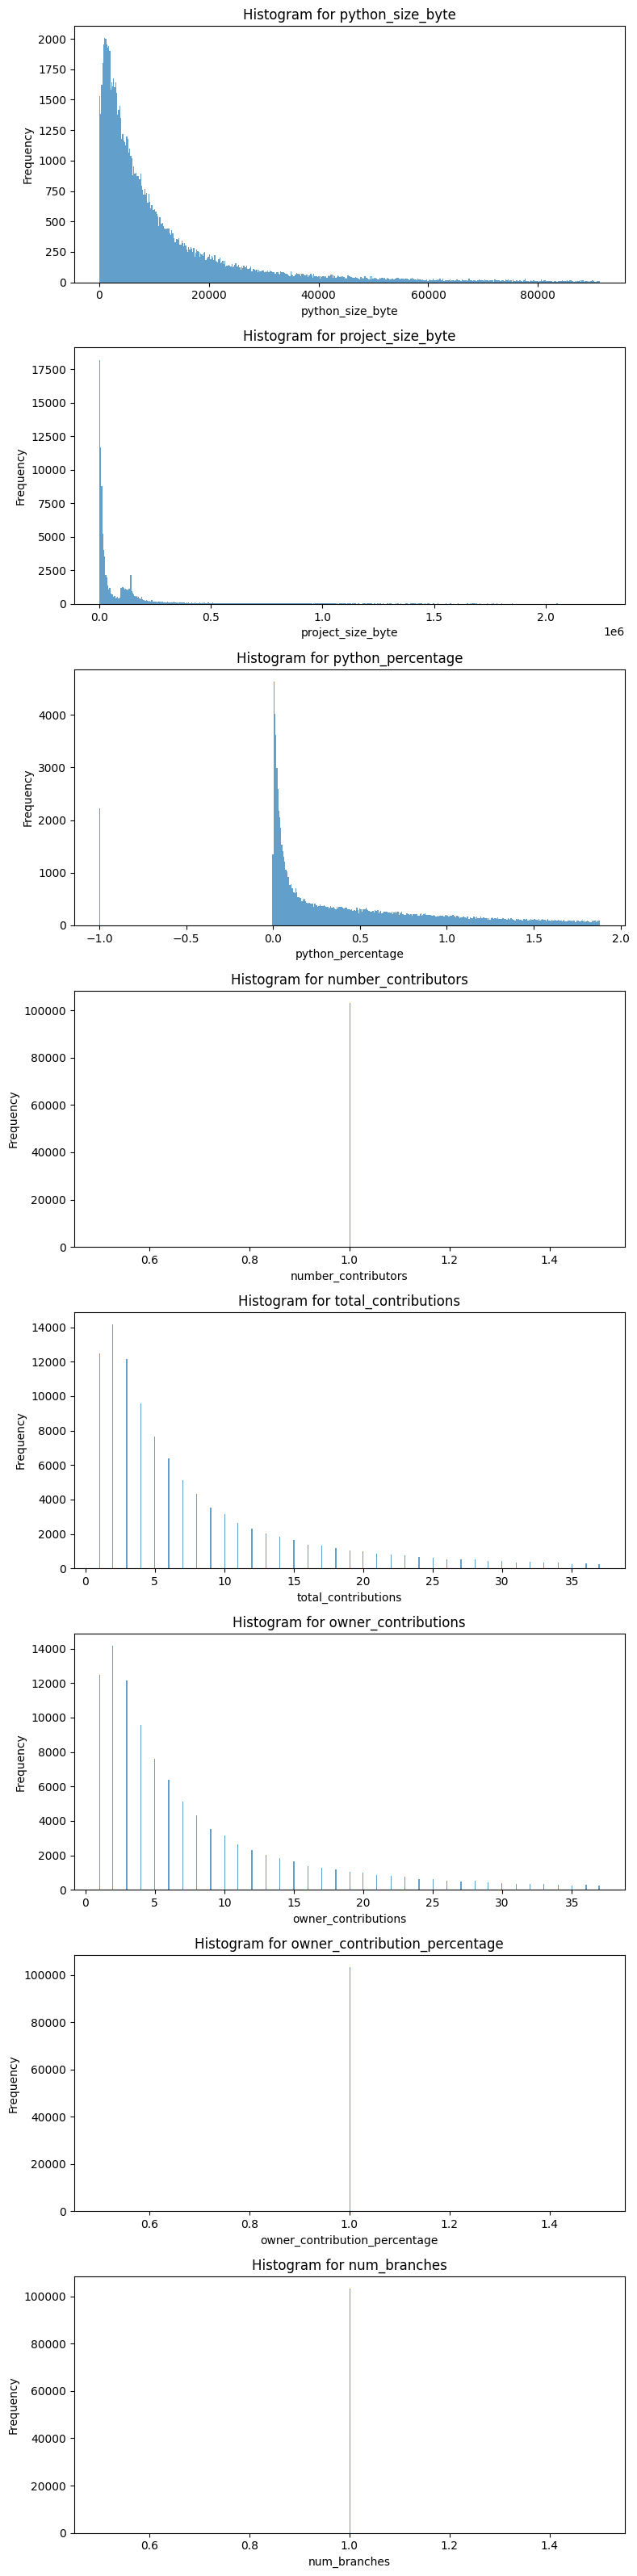

In [12]:
# Based on the thresholds, we trim the data
df_statistics_filtered = df_statistics.copy()
for column_name in df_statistics.columns:
    thresholds = get_outliers_IQR(df_statistics, column_name)
    df_statistics_filtered = remove_outliers(df_statistics_filtered, column_name, *thresholds)

# Now print the results

num_columns = len(df_statistics_filtered.columns)
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(8, 4 * num_columns))
for i, column in enumerate(df_statistics_filtered.columns):
    ax = axes[i] if num_columns > 1 else axes
    plot_hist_subplot(df_statistics_filtered, column, ax)
# Adjust layout
plt.tight_layout()
plt.show()

In [13]:
df_statistics_filtered

,python_size_byte,project_size_byte,python_percentage,number_contributors,total_contributions,owner_contributions,owner_contribution_percentage,num_branches
2,1857,110592,0.016791,1,3,3,1.0,1
4,23925,72704,0.329074,1,9,9,1.0,1
8,2872,2048,1.402344,1,3,3,1.0,1
9,5701,6144,0.927897,1,12,12,1.0,1
11,335,1024,0.327148,1,1,1,1.0,1
...,...,...,...,...,...,...,...,...
232303,1901,3072,0.618815,1,5,5,1.0,1
232304,554,36864,0.015028,1,3,3,1.0,1
232305,2455,7168,0.342494,1,8,8,1.0,1
232307,5223,245760,0.021252,1,5,5,1.0,1


# Perform Filtering
Filter out the outlier repos, and then filter users with these repos. 

In [14]:
df_python_repos_filtered = df_python_repos.loc[df_statistics_filtered.index]

In [15]:
df_python_repos_filtered = pd.concat([df_python_repos_filtered, df_statistics_filtered], axis=1)

In [ ]:
df_python_repos_filtered.to_csv('Database/TempData/GatherData/Filter_3_UserRepositories/Results/df_repos_filter_3.csv', index=False)

In [17]:
# save filtered python repo to csv to each user's directory
grouped = df_python_repos_filtered.groupby('user_login')
base_directory = "Database/UserData"
# Iterate over each group
for user_login, user_repos in tqdm(grouped):
    # Define the user's directory path
    user_dir = os.path.join(base_directory, user_login)
    
    # Ensure the directory exists
    os.makedirs(user_dir, exist_ok=True)
    
    # Path for the CSV file
    csv_path = os.path.join(user_dir, "filtered_python_repos.csv")
    
    # Write the user's repositories to a CSV file
    user_repos.to_csv(csv_path, index=False)


100%|████████████████████████████████████████████████████████████████████████████| 28740/28740 [00:32<00:00, 877.33it/s]


# Select only American or Chinese from the df...

In [17]:
# In filter 2 we didn't filter out users, we just add country to them 
# But in repos we only added details for those who are American or Chinese, 
# So we basically filter all americans/chinese below by inner join with the repos list. 
df_users = pd.read_csv("Database/TempData/GatherData/Filter_2_DecypherLocation/Results/users_filter_2.csv")
df_python_repos_filtered = pd.read_csv('Database/TempData/GatherData/Filter_3_UserRepositories/Results/df_repos_filter_3.csv')

In [18]:
# double check if this merge is correct
df_python_repos_filtered['user_login'].nunique()

28740

In [20]:
# Only keep the users that have repositories in the filtered_python_repos
df_users_filtered = pd.merge(df_users, df_python_repos_filtered['user_login'], left_on='login', right_on='user_login', how='inner')
df_users_filtered = df_users_filtered.drop_duplicates()
# drop the duplicated column: user_login
df_users_filtered.drop(columns=['user_login'], inplace=True)
df_users_filtered.reset_index(drop=True, inplace=True)
df_users_filtered.to_csv('Database/TempData/GatherData/Filter_3_UserRepositories/Results/df_users_filter_3.csv', index=False)
len(df_users_filtered)

28740

In [21]:
len(df_users_filtered[df_users_filtered['country']=='China'])

7576

In [22]:
len(df_users_filtered[df_users_filtered['country']=='United States'])

21164

In [24]:
# load example
df_repos = pd.read_csv("Database/TempData/GatherData/Filter_3_UserRepositories/Results/df_repos_filter_3.csv")
df_users = pd.read_csv('Database/TempData/GatherData/Filter_3_UserRepositories/Results/df_users_filter_3.csv')
len(df_repos), len(df_users)

(103244, 28740)